# Recourse

In [151]:
#%%
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [189]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import torch
import pandas as pd
import numpy as np
from functools import partial
from pathlib import Path
import logging
from itertools import combinations

from monoculture.analysis.setup import ACS_TASKS, TABLESHIFT_TASKS, baselines
from monoculture.analysis.utils import (
    key_to_model,
    get_size_and_it,
    load_model_outputs_same_prompt,
    get_metric,
    load_task_data,
)
from monoculture.baseline.utils import load_baselines
from monoculture.analysis.metrics import get_fraction_no_recourse, poisson_binom_agreement, get_ambiguity, get_discrepancy

import matplotlib.ticker as ticker


In [190]:
plot_config_file = "./results/.matplotlibrc"
plt.rcParams.update(mpl.rc_params_from_file(fname=plot_config_file))

TASKS = ACS_TASKS + TABLESHIFT_TASKS
print("tasks", TASKS)

RESULTS_ROOT_DIR = Path("./results/")
results_df_path = RESULTS_ROOT_DIR / "overview_results_by_prompt_style.csv"
FIGURES_ROOT_DIR = RESULTS_ROOT_DIR / "figures/same-prompt"
FIGURES_PAPER_DIR = RESULTS_ROOT_DIR / "figures/paper/same-prompt/"

tasks ('ACSIncome', 'ACSEmployment', 'ACSMobility', 'ACSTravelTime', 'ACSPublicCoverage', 'BRFSS_Diabetes', 'BRFSS_Blood_Pressure')


In [ ]:
data_all = None

## Load predictions

In [291]:
num_shots = 0
threshold_fitted = 1

df = pd.read_csv(results_df_path)
# restrict to zero-shot and same prompt style
df_same_prompt = df[
    (df["num_shots"] == num_shots)
    & (df["prompt_format"] == "bullet")
    & (df["prompt_connector"] == "is")
    & (df["prompt_granularity"] == "original")
    & (df["prompt_feature_order"] == "default")
    & (df["threshold_fitted"] == threshold_fitted)
]
df_same_prompt.head()

,task,model,is_inst,threshold_fitted,threshold,accuracy,bench_hash,num_shots,prompt_format,prompt_connector,prompt_granularity,prompt_feature_order,eval_results_path,predictions_path
1,ACSIncome,meta-llama--Meta-Llama-3.2-1B-Instruct,1,1,0.776744,0.680409,3019759728,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-meta-llama...,results/folktexts/0-bullet-is/model-meta-llama...
2,ACSIncome,allenai--OLMo-2-1124-7B-Instruct,1,1,0.904552,0.727768,3118177042,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-allenai--O...,results/folktexts/0-bullet-is/model-allenai--O...
4,ACSIncome,google--gemma-2-27b,0,1,0.438475,0.510381,3621160589,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-google--ge...,results/folktexts/0-bullet-is/model-google--ge...
6,ACSIncome,google--gemma-2-27b-it,1,1,0.867235,0.659718,1712994131,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-google--ge...,results/folktexts/0-bullet-is/model-google--ge...
9,ACSIncome,meta-llama--Meta-Llama-3-70B,0,1,0.532134,0.763641,4121241683,0,bullet,is,original,default,results/folktexts/0-bullet-is/model-meta-llama...,results/folktexts/0-bullet-is/model-meta-llama...


In [292]:
print(df_same_prompt.shape)
try:
    assert set(TASKS).issubset(
        set(df_same_prompt["task"].unique())
    ), f"Results for all tasks to be analysed have to be available, available are: {list(df_same_prompt['task'].unique())} "
except AssertionError:
    logging.warning("Reduced TASKS to available tasks.")
    TASKS = list(set(df_same_prompt["task"].unique()).intersection(TASKS))
TASKS

(342, 14)


('ACSIncome',
 'ACSEmployment',
 'ACSMobility',
 'ACSTravelTime',
 'ACSPublicCoverage',
 'BRFSS_Diabetes',
 'BRFSS_Blood_Pressure')

In [293]:
risk_scores = load_model_outputs_same_prompt(
    df_same_prompt, tasks=TASKS, return_risk_scores=True
)
predictions_all = load_model_outputs_same_prompt(
    df_same_prompt, tasks=TASKS, return_risk_scores=False
)

metrics = [
    "n_samples",
    "accuracy",
    "fpr",
    "fnr",
    "ppr",
    "num_pred_negatives",
    "num_pred_positives",
    "balanced_accuracy",
]
for metric in metrics:
    df_same_prompt[metric] = (
        df_same_prompt["eval_results_path"]
        .apply(partial(get_metric, metric=metric))
        .copy()
    )

evals_per_task_all = {}  # [task][metric][model]
for task in TASKS:
    df_task = df_same_prompt[df_same_prompt["task"] == task]
    evals_per_task_all[task] = {
        metric: {model: val for model, val in zip(df_task["model"], df_task[metric])}
        for metric in metrics
    }

ACSIncome
ACSEmployment
ACSMobility
ACSTravelTime
ACSPublicCoverage
BRFSS_Diabetes
BRFSS_Blood_Pressure
ACSIncome
ACSEmployment
ACSMobility
ACSTravelTime
ACSPublicCoverage
BRFSS_Diabetes
BRFSS_Blood_Pressure


/var/folders/94/0gpvl07x6ks__mzyr78t4gg00006zk/T/ipykernel_52653/153609021.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_same_prompt[metric] = (
/var/folders/94/0gpvl07x6ks__mzyr78t4gg00006zk/T/ipykernel_52653/153609021.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_same_prompt[metric] = (
/var/folders/94/0gpvl07x6ks__mzyr78t4gg00006zk/T/ipykernel_52653/153609021.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,c

## Restrict analysis to models based on performance or true labels?

In [294]:
restrict_to_better_const = False
restrict_to_non_const = True
restrict_to_positive_label = True
restrict_to_negative_label = False
assert not (
    restrict_to_positive_label & restrict_to_negative_label
), "Choose one or none."

restrict_to_model_family = False  #'Llama'  # name of family
restrict_to_base_models = False
restrict_to_it_models = False
assert not (restrict_to_base_models and restrict_to_it_models), "Choose one or none."

restrict_to_top_eps = False #True
restrict_to_topk = False
topk = 10
eps = 0.05

predictions = predictions_all.copy()

if data_all:
    data = data_all.copy()
    
if any(
    [restrict_to_better_const,restrict_to_positive_label, restrict_to_negative_label]
):
    if not data_all:
        logging.warning("Load task data")
        data_all = load_task_data(TASKS, Path("./data"))
        data = data_all.copy()
    elif not all([t in data.keys()for t in TASKS]):
        for t in TASKS:
            if t not in data.keys():
                print(f'add {t} to data')
                data_t =load_task_data(t, Path("./data"))
                data_all.update(data_t)
                data = data_all.copy()

    for task in sorted(TASKS):
        df_task = df_same_prompt[df_same_prompt["task"] == task]
        y_true = data[task][1]

        if restrict_to_better_const:
            const_acc = max((y_true == 1).sum(), (y_true == 0).sum()) / y_true.shape[0]
            models_better_const = sorted(
                df_task["model"][df_task["accuracy"] > const_acc].to_list(),
                key=get_size_and_it,
            )
            predictions[task] = predictions[task].filter(items=models_better_const)
            # df_same_prompt[df_same_prompt["task"] == task] = df_same_prompt[df_same_prompt["task"] == task].filter(items=models_better_const)

        if restrict_to_negative_label or restrict_to_positive_label:
            filter_idx = y_true[y_true == int(restrict_to_positive_label)].index
            predictions[task] = predictions[task].loc[filter_idx]
        print(task, predictions[task].shape)


# if restrict_to_non_const:
#     for task in TASKS:
#         predictions[task].sum(axis=0)
#         # predictions[task] = predictions[task].filter(items=models)

if restrict_to_topk or restrict_to_top_eps:
    assert not (restrict_to_top_eps and restrict_to_topk)
    for task in TASKS:
        df_task_sorted_by_acc = df_same_prompt[
            df_same_prompt["task"] == task
        ].sort_values(by="accuracy", ascending=False)
        if restrict_to_topk:
            models = sorted(
                df_task_sorted_by_acc.iloc[:topk]["model"].to_list(),
                key=get_size_and_it,
            )
            predictions[task] = predictions[task].filter(items=models)
            # df_same_prompt[df_same_prompt["task"] == task] =df_same_prompt[df_same_prompt["task"] == task].filter(items=models)
        if restrict_to_top_eps:
            top_acc = df_task_sorted_by_acc.iloc[0]["accuracy"].item()
            models = sorted(
                df_task_sorted_by_acc[
                    df_task_sorted_by_acc["accuracy"] > top_acc - eps
                ]["model"].to_list(),
                key=get_size_and_it,
            )
            predictions[task] = predictions[task].filter(items=models)
            df_same_prompt[df_same_prompt["task"] == task] = df_task_sorted_by_acc[
                    df_task_sorted_by_acc["accuracy"] > top_acc - eps
                ]
        print(task, predictions[task].shape)

if restrict_to_model_family:
    print(f"Restrict to model family {restrict_to_model_family}")
    for task in TASKS:
        models_filtered = list(
            df_same_prompt[
                df_same_prompt.apply(
                    lambda row: (row.task == task)
                    & (row.model in predictions[task].columns)
                    & (restrict_to_model_family in row.model),
                    axis=1,
                )
            ]["model"].unique()
        )
        print(len(models_filtered))
        predictions[task] = predictions[task].filter(items=models_filtered)
        # df_same_prompt[df_same_prompt["task"] == task] = df_same_prompt[df_same_prompt["task"] == task].filter(items=models_filtered)
        print(task, predictions[task].shape)

if any([restrict_to_base_models, restrict_to_it_models]):
    for task in TASKS:
        models_filtered = list(
            df_same_prompt[
                df_same_prompt.apply(
                    lambda row: (row.task == task)
                    & (row.model in predictions[task].columns)
                    & (row.is_inst == int(restrict_to_it_models)),
                    axis=1,
                )
            ]["model"].unique()
        )
        predictions[task] = predictions[task].filter(items=models_filtered)
        print(task, predictions[task].shape)

evals_per_task = {
    task: {
        metric: {
            model: evals_per_task_all[task][metric][model]
            for model in predictions[task].columns
        }
        for metric in evals_per_task_all[task].keys()
    }
    for task in evals_per_task_all.keys()
}

ACSEmployment (146740, 49)
ACSIncome (61233, 50)
ACSMobility (16446, 47)
ACSPublicCoverage (33971, 50)
ACSTravelTime (64285, 50)
BRFSS_Blood_Pressure (44586, 48)
BRFSS_Diabetes (19119, 48)


In [295]:
# for task in TASKS: 
#     if predictions[task].isna().any().any():
#         print(f"{task}: {predictions[task][predictions[task].isna().any(axis=1)].shape[0]} NaN values found, dropping these.")
#         valid_idx = predictions[task].dropna().index
#         predictions[task]= predictions[task].loc[valid_idx]
#         data[task] = (data[task][0].loc[valid_idx], data[task][1].loc[valid_idx])
#         print("Remaining: ", predictions[task].shape, data[task][1].shape)
        

## Systemic Failure (No Recourse) as a function of the Rashomon Set Size

In [296]:
no_recourse = {}
epsilon_per_task = {}
multiplicity_measures = {}


for task in sorted(TASKS):
    no_recourse[task] = {}
    multiplicity_measures[task] = {}

    df_task_sorted_by_acc = df_same_prompt[df_same_prompt["task"] == task].sort_values(
        by="accuracy", ascending=False
    )
    top_acc = df_task_sorted_by_acc.iloc[0]["accuracy"].item()
    top_model = df_task_sorted_by_acc.iloc[0]["model"]
    max_eps = 0.05
    y_true = data[task][1]
    const_acc = max((y_true == 1).sum(), (y_true == 0).sum()) / y_true.shape[0]
    print(f"{task} top: {top_acc:.4f} const: {const_acc:.4f} diff: {top_acc - const_acc:0.4f}")
    
    
    # epsilon = np.arange(0, top_acc - const_acc+0.005, 0.005)
    epsilon = np.arange(0,max_eps+0.005, 0.005)
    epsilon_per_task[task] = epsilon

    no_recourse_observed = []
    no_recourse_at_random = []
    num_models = []
    ambiguities = []
    discrepancies = []

    for eps in epsilon:
        mask = (df_task_sorted_by_acc["accuracy"] >= top_acc - eps)
        if restrict_to_better_const:
            mask &= (df_task_sorted_by_acc["accuracy"] >= const_acc)
        models = sorted(
            df_task_sorted_by_acc[mask][
                "model"
            ].to_list(),
            key=get_size_and_it,
        )

        tp_rates = [1. - evals_per_task_all[task]['fnr'][model] for model in models]
        filtered_df = predictions[task].filter(items=models)

        if len(models) > 0 and predictions[task].shape[1] > 0:
            no_recourse_observed.append(
                get_fraction_no_recourse(
                    predictions[task].filter(items=models).to_numpy()
                )
            )
            no_recourse_at_random.append(poisson_binom_agreement(baseline_rate=tp_rates, k=0))
            num_models.append(len(models))
            ambiguities.append(get_ambiguity(h0_predictions=filtered_df[top_model], predictions=filtered_df))
            discrepancies.append(get_discrepancy(h0_predictions=filtered_df[top_model], predictions=filtered_df))

    if predictions[task].shape[1] > 0:
        no_recourse[task] = {
            "eps": epsilon,
            "$|\mathcal{R_\epsilon}|$": num_models,
            "observed": no_recourse_observed,
            "random_error": no_recourse_at_random,
        }
        multiplicity_measures[task] = {
            "eps": epsilon,
            "$|\mathcal{R_\epsilon}|$": num_models,
            "ambiguity": np.array(ambiguities),
            "discrepancy": np.array(discrepancies),
        }
    print(task, no_recourse[task])

ACSEmployment top: 0.7998 const: 0.5466 diff: 0.2533
ACSEmployment {'eps': array([0.   , 0.005, 0.01 , 0.015, 0.02 , 0.025, 0.03 , 0.035, 0.04 ,
       0.045, 0.05 ]), '$|\\mathcal{R_\\epsilon}|$': [1, 2, 3, 4, 4, 6, 6, 6, 6, 7, 7], 'observed': [0.151008586615783, 0.1351233474172005, 0.12677524873926674, 0.09062968515742129, 0.09062968515742129, 0.07494207441733679, 0.07494207441733679, 0.07494207441733679, 0.07494207441733679, 0.06285266457680251, 0.06285266457680251], 'random_error': [0.15100858661578298, 0.02744272849450106, 0.005535673732024202, 0.0007822147664816805, 0.0007822147664816805, 3.526180385299181e-05, 3.526180385299181e-05, 3.526180385299181e-05, 3.526180385299181e-05, 7.054523481751946e-06, 7.054523481751946e-06]}
ACSIncome top: 0.7885 const: 0.6321 diff: 0.1564
NaNs contained
reduces to (61233,)
NaNs contained
reduces to (61233,)
NaNs contained
reduces to (61233,)
NaNs contained
reduces to (61233,)
NaNs contained
reduces to (61233,)
NaNs contained
reduces to (61233,)


/Users/mgorecki/Documents/projects/monoculture/monoculture/analysis/metrics.py:136: RuntimeWarning: invalid value encountered in cast
  row_wise_or = np.bitwise_or.reduce(predictions_array, axis=1)
/Users/mgorecki/Documents/projects/monoculture/monoculture/analysis/metrics.py:136: RuntimeWarning: invalid value encountered in cast
  row_wise_or = np.bitwise_or.reduce(predictions_array, axis=1)
/Users/mgorecki/Documents/projects/monoculture/monoculture/analysis/metrics.py:136: RuntimeWarning: invalid value encountered in cast
  row_wise_or = np.bitwise_or.reduce(predictions_array, axis=1)
/Users/mgorecki/Documents/projects/monoculture/monoculture/analysis/metrics.py:136: RuntimeWarning: invalid value encountered in cast
  row_wise_or = np.bitwise_or.reduce(predictions_array, axis=1)
/Users/mgorecki/Documents/projects/monoculture/monoculture/analysis/metrics.py:136: RuntimeWarning: invalid value encountered in cast
  row_wise_or = np.bitwise_or.reduce(predictions_array, axis=1)
/Users/mgo

NaNs contained
reduces to (33971,)
NaNs contained
reduces to (33971,)
NaNs contained
reduces to (33971,)
NaNs contained
reduces to (33971,)
ACSPublicCoverage {'eps': array([0.   , 0.005, 0.01 , 0.015, 0.02 , 0.025, 0.03 , 0.035, 0.04 ,
       0.045, 0.05 ]), '$|\\mathcal{R_\\epsilon}|$': [1, 3, 4, 5, 7, 10, 15, 18, 21, 23, 24], 'observed': [0.5501162756468753, 0.4096140825998646, 0.36875570339407143, 0.31085337493744664, 0.2545406376026611, 0.2309617026287127, 0.20376203232168613, 0.17691560448617938, 0.1561920461570163, 0.14165023107945013, 0.1362044096435195], 'random_error': [0.5501162756468753, 0.11592225891723157, 0.07161580312313265, 0.03575203571178965, 0.009136802712749808, 0.00366190575365881, 0.0003573487457420445, 0.00010199111363720447, 2.3894591766070105e-05, 6.300898554220527e-06, 4.6173079570447096e-06]}
ACSTravelTime top: 0.6455 const: 0.5617 diff: 0.0838
NaNs contained
reduces to (64285,)
NaNs contained
reduces to (64285,)
NaNs contained
reduces to (64285,)
NaNs contai

no-recourse-multiplicity-0-shot_tresh_fitted_pos_instances


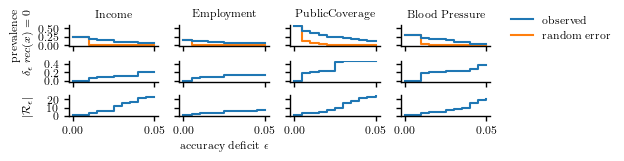

In [299]:
tasks_to_plot = [task for task in TASKS if task not in ['BRFSS_Diabetes','ACSMobility', 'ACSTravelTime']]  # ['ACSIncome', 'ACSEmployment', 'BRFSS_Blood_Pressure']
measures = ["no_recourse", 
            # "ambiguity", 
            "discrepancy", 
            "$|\mathcal{R_\epsilon}|$"]

default_width = plt.rcParams['figure.figsize'][0] * 0.9
custom_height = 1.5 #plt.rcParams['figure.figsize'][1]

fig, axs = plt.subplots(
    len(measures),
    len(tasks_to_plot),
    figsize=(default_width, custom_height),
    constrained_layout=True,
    sharey="row",
    sharex=True
)

for m, measure in enumerate(measures):
    ymin=100
    ymax=0
    for t, task in enumerate(tasks_to_plot):
        if len(no_recourse[task]) > 0:
            if m == 0:
                axs[m, t].step(
                    no_recourse[task]["eps"],
                    no_recourse[task]["random_error"],
                    where="post",
                    color="C1",
                    label="random error",
                )
                axs[m, t].step(
                    no_recourse[task]["eps"],
                    no_recourse[task]["observed"],
                    where="post",
                    color="C0",
                    label="observed",
                )
            else:
                axs[m, t].step(
                    multiplicity_measures[task]["eps"],
                    multiplicity_measures[task][measure],
                    color="C0",
                    where="post",
                )
                # axs[m, t].scatter(
                #     multiplicity_measures[task]["eps"],
                #     multiplicity_measures[task][measure],
                #     color="C0",
                # )
        else:
            axs[m, t].set_axis_off()
        axs[0,t].set_title(task.replace("ACS", "").replace("BRFSS", "").replace("_", " "))
    if measure=='no_recourse':
        axs[m,0].set_ylabel("prevalence\n" "$rec(x)=0$")
    elif measure== 'discrepancy':
        axs[m,0].set_ylabel("$\delta_{\epsilon}$")
    else:
        axs[m,0].set_ylabel(measure)
    #yticks = np.linspace(ymin, ymax, num=4)
    #axs[m,0].set_yticks(yticks, [f"{tick:.2f}" for tick in yticks])
    
# axs[0].legend()
axs[-1,len(tasks_to_plot) // 2-1].set_xlabel(r"accuracy deficit $\epsilon$")
for ax in axs.flat:
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=3, prune='both'))

fig.align_ylabels(axs[:, 0])
# legend
# legend
desired_order = ['observed', 'random error', 'random prediction', 'monoculture']
handles, labels = axs[0,0].get_legend_handles_labels()
unique = {}
for h, l in zip(handles, labels):
    if l not in unique:
        unique[l] = h
ordered_labels = [label for label in desired_order if label in unique]
ordered_handles = [unique[label] for label in ordered_labels]
# positioning
# get the bottom-most y-position among all axes
lowest_ax_y = min([ax.get_position().y0 for ax in axs.flat])

fig.legend(
    ordered_handles,
    ordered_labels,
    loc="upper left",
    # ncol=len(labels),
    bbox_to_anchor=(1.0, 1.0),
    frameon=False,  # show box
    framealpha=1.0,  # opacity of box
    edgecolor="black",  # border color
    fancybox=True,
)  # rounded corners)
# plt.legend(handles, labels, loc="upper left", bbox_to_anchor=(1.0, 1.0))

file_name = "".join(
    [
        f"no-recourse-multiplicity-{num_shots}-shot",
        "_tresh_fitted" if threshold_fitted == 1 else "",
        "_better_const" if restrict_to_better_const else "",
        "_pos_instances" if restrict_to_positive_label else "",
        "_neg_instances" if restrict_to_negative_label else "",
    ]
)
for ending in [".png", ".pdf"]:
    plt.savefig(FIGURES_ROOT_DIR / (file_name + ending))
    plt.savefig(FIGURES_PAPER_DIR / (file_name + ending))
print(file_name)

plt.show()

no-recourse-multiplicity-0-shot_tresh_fitted_pos_instances


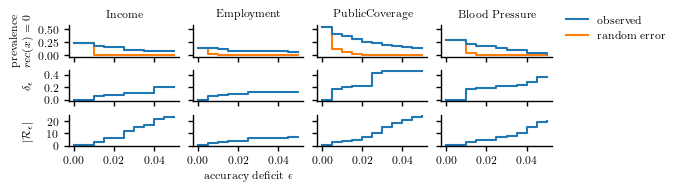

In [307]:
tasks_to_plot = [task for task in TASKS if task not in ['BRFSS_Diabetes','ACSMobility', 'ACSTravelTime']]  # ['ACSIncome', 'ACSEmployment', 'BRFSS_Blood_Pressure']
measures = ["no_recourse", 
            # "ambiguity", 
            "discrepancy", 
            "$|\mathcal{R_\epsilon}|$"]

default_width = plt.rcParams['figure.figsize'][0]
custom_height = 1.8 #plt.rcParams['figure.figsize'][1]

fig, axs = plt.subplots(
    len(measures),
    len(tasks_to_plot),
    figsize=(default_width, custom_height),
    constrained_layout=True,
    sharey="row",
    sharex=True
)

for m, measure in enumerate(measures):
    ymin=100
    ymax=0
    for t, task in enumerate(tasks_to_plot):
        if len(no_recourse[task]) > 0:
            if m == 0:
                axs[m, t].step(
                    no_recourse[task]["eps"],
                    no_recourse[task]["random_error"],
                    where="post",
                    color="C1",
                    label="random error",
                )
                axs[m, t].step(
                    no_recourse[task]["eps"],
                    no_recourse[task]["observed"],
                    where="post",
                    color="C0",
                    label="observed",
                )
            else:
                axs[m, t].step(
                    multiplicity_measures[task]["eps"],
                    multiplicity_measures[task][measure],
                    color="C0",
                    where="post",
                )
                # axs[m, t].scatter(
                #     multiplicity_measures[task]["eps"],
                #     multiplicity_measures[task][measure],
                #     color="C0",
                # )
        else:
            axs[m, t].set_axis_off()
        axs[0,t].set_title(task.replace("ACS", "").replace("BRFSS", "").replace("_", " "))
    if measure=='no_recourse':
        axs[m,0].set_ylabel("prevalence\n" "$rec(x)=0$")
    elif measure== 'discrepancy':
        axs[m,0].set_ylabel("$\delta_{\epsilon}$")
    else:
        axs[m,0].set_ylabel(measure)
    #yticks = np.linspace(ymin, ymax, num=4)
    #axs[m,0].set_yticks(yticks, [f"{tick:.2f}" for tick in yticks])
    
# axs[0].legend()
axs[-1,len(tasks_to_plot) // 2-1].set_xlabel(r"accuracy deficit $\epsilon$")
for ax in axs.flat:
    ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=3, prune='both'))

fig.align_ylabels(axs[:, 0])
# legend
# legend
desired_order = ['observed', 'random error', 'random prediction', 'monoculture']
handles, labels = axs[0,0].get_legend_handles_labels()
unique = {}
for h, l in zip(handles, labels):
    if l not in unique:
        unique[l] = h
ordered_labels = [label for label in desired_order if label in unique]
ordered_handles = [unique[label] for label in ordered_labels]
# positioning
# get the bottom-most y-position among all axes
lowest_ax_y = min([ax.get_position().y0 for ax in axs.flat])

fig.legend(
    ordered_handles,
    ordered_labels,
    loc="upper left",
    # ncol=len(labels),
    bbox_to_anchor=(1.0, 1.0),
    frameon=False,  # show box
    framealpha=1.0,  # opacity of box
    edgecolor="black",  # border color
    fancybox=True,
)  # rounded corners)
# plt.legend(handles, labels, loc="upper left", bbox_to_anchor=(1.0, 1.0))

file_name = "".join(
    [
        f"no-recourse-multiplicity-{num_shots}-shot",
        "_tresh_fitted" if threshold_fitted == 1 else "",
        "_better_const" if restrict_to_better_const else "",
        "_pos_instances" if restrict_to_positive_label else "",
        "_neg_instances" if restrict_to_negative_label else "",
    ]
)
for ending in [".png", ".pdf"]:
    plt.savefig(FIGURES_ROOT_DIR / (file_name + ending))
    plt.savefig(FIGURES_PAPER_DIR / (file_name + ending))
print(file_name)

plt.show()

In [260]:
m = no_recourse[task][r'$|\mathcal{R_\epsilon}|$'][np.where(no_recourse[task]['eps']==0.01)[0][0]]
df_same_prompt[df_same_prompt['task']=='ACSIncome'].sort_values(by='accuracy', ascending=False).iloc[:m]

,task,model,is_inst,threshold_fitted,threshold,accuracy,bench_hash,num_shots,prompt_format,prompt_connector,...,prompt_feature_order,eval_results_path,predictions_path,n_samples,fpr,fnr,ppr,num_pred_negatives,num_pred_positives,balanced_accuracy
90,ACSIncome,meta-llama--Meta-Llama-3.3-70B-Instruct,1,1,0.999292,0.788483,364117336,0,bullet,is,...,default,results/folktexts/0-bullet-is/model-meta-llama...,results/folktexts/0-bullet-is/model-meta-llama...,166450,0.198019,0.234710,0.406705,98754,67696,0.783635
65,ACSIncome,Qwen--Qwen2.5-72B,0,1,0.320242,0.780667,3802773871,0,bullet,is,...,default,results/folktexts/0-bullet-is/model-Qwen--Qwen...,results/folktexts/0-bullet-is/model-Qwen--Qwen...,166450,0.214747,0.227214,0.420036,96535,69915,0.779020
88,ACSIncome,mistralai--Mistral-Small-24B-Instruct-2501,1,1,0.867116,0.780366,3235594015,0,bullet,is,...,default,results/folktexts/0-bullet-is/model-mistralai-...,results/folktexts/0-bullet-is/model-mistralai-...,166450,0.202933,0.248330,0.404800,99071,67379,0.774368


In [302]:
# latex table
print(eps)
print(num_shots)
print(f"{'task':20}& M &{'ambiguity':14}&{'discrepancy':20}\\\\" )
for task in TASKS:
        df_task_sorted_by_acc = df_same_prompt[df_same_prompt["task"] == task].sort_values(
        by="accuracy", ascending=False
         )
        top_acc = df_task_sorted_by_acc.iloc[0]["accuracy"].item()
        top_model = df_task_sorted_by_acc.iloc[0]["model"]
        models = sorted(
                df_task_sorted_by_acc[
                    df_task_sorted_by_acc["accuracy"] > top_acc - eps
                ]["model"].to_list(),
                key=get_size_and_it,
            )
        tmp_filtered_preds = predictions[task].filter(items=models)  
        print(f"{task.replace('_', ' '):20}&{tmp_filtered_preds.shape[1]}& {get_ambiguity(tmp_filtered_preds[top_model], tmp_filtered_preds):.3f}&{get_discrepancy(tmp_filtered_preds[top_model], tmp_filtered_preds):.3f}\\\\" )

0.05
0
task                & M &ambiguity     &discrepancy         \\
NaNs contained
reduces to (61233,)
ACSIncome           &23& 0.394&0.207\\
ACSEmployment       &7& 0.284&0.132\\
ACSMobility         &5& 0.322&0.197\\
NaNs contained
reduces to (64285,)
ACSTravelTime       &10& 0.617&0.253\\
NaNs contained
reduces to (33971,)
ACSPublicCoverage   &24& 0.864&0.452\\
BRFSS Diabetes      &2& 0.089&0.089\\
BRFSS Blood Pressure&20& 0.794&0.358\\


In [201]:
tmp_filtered_preds[[top_model, 'Qwen--Qwen2.5-7B-Instruct']]

,gpt-4.1,Qwen--Qwen2.5-7B-Instruct
723936,1,1
469143,1,0
373783,1,0
651676,1,1
430321,1,1
...,...,...
62634,1,0
577474,0,0
99268,1,1
98005,1,1


In [202]:
get_discrepancy(tmp_filtered_preds[top_model], tmp_filtered_preds)

0.35762346925043736

In [203]:
tmp_filtered_preds.ne(tmp_filtered_preds[top_model], axis=0).sum(axis=0).sort_values()

gpt-4.1                                           0
meta-llama--Meta-Llama-3.1-70B-Instruct        7261
Qwen--Qwen2.5-72B-Instruct                     7391
meta-llama--Meta-Llama-3-70B-Instruct          7466
meta-llama--Meta-Llama-3.3-70B-Instruct        8069
meta-llama--Meta-Llama-3.1-70B                 8605
Qwen--Qwen2-72B                                8639
mistralai--Mixtral-8x7B-Instruct-v0.1          9523
mistralai--Mistral-Small-24B-Base-2501         9801
01-ai--Yi-34B-Chat                            10060
Qwen--Qwen2-72B-Instruct                      10487
meta-llama--Meta-Llama-3-8B-Instruct          10795
01-ai--Yi-6B-Chat                             11917
gpt-3.5-turbo-0125                            12167
Qwen--Qwen2.5-7B-Instruct                     12277
google--gemma-2-9b-it                         12523
Qwen--Qwen2.5-72B                             13133
meta-llama--Meta-Llama-3-70B                  13413
mistralai--Mistral-7B-Instruct-v0.2           14204
mistralai--M

In [206]:
get_ambiguity(tmp_filtered_preds[top_model][:10], tmp_filtered_preds[:10])

0.9

,01-ai--Yi-6B-Chat,Qwen--Qwen2.5-7B-Instruct,mistralai--Mistral-7B-Instruct-v0.2,meta-llama--Meta-Llama-3-8B-Instruct,google--gemma-2-9b-it,mistralai--Mistral-Small-24B-Base-2501,mistralai--Mistral-Small-24B-Instruct-2501,01-ai--Yi-34B-Chat,mistralai--Mixtral-8x7B-Instruct-v0.1,meta-llama--Meta-Llama-3.1-70B,meta-llama--Meta-Llama-3-70B,meta-llama--Meta-Llama-3.3-70B-Instruct,meta-llama--Meta-Llama-3.1-70B-Instruct,meta-llama--Meta-Llama-3-70B-Instruct,Qwen--Qwen2-72B,Qwen--Qwen2.5-72B,Qwen--Qwen2.5-72B-Instruct,Qwen--Qwen2-72B-Instruct,gpt-4.1,gpt-3.5-turbo-0125
723936,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
469143,1,0,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
373783,1,0,0,0,0,1,1,1,0,1,1,1,1,1,1,0,0,0,1,0
651676,1,1,0,1,1,1,1,0,0,1,1,1,1,1,1,0,0,0,1,1
430321,1,1,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1
130771,1,0,1,0,1,0,1,1,1,0,0,1,0,0,0,0,0,0,0,1
81614,0,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1
331115,1,0,0,0,0,0,1,1,1,0,0,1,0,0,0,0,1,0,0,0
133369,1,1,0,1,1,1,1,0,1,1,1,1,1,1,1,0,1,0,1,1
431243,0,0,0,1,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0


In [231]:
ref = tmp_filtered_preds[top_model][:4]
df_test = tmp_filtered_preds.iloc[:4, :3]
ref

723936    1
469143    1
373783    1
651676    1
Name: gpt-4.1, dtype: int64

In [232]:
df_test.iloc[0,0] = np.nan

In [233]:
df_test

,01-ai--Yi-6B-Chat,Qwen--Qwen2.5-7B-Instruct,mistralai--Mistral-7B-Instruct-v0.2
723936,NaN,1,1
469143,1.0,0,1
373783,1.0,0,0
651676,1.0,1,0


In [221]:
get_ambiguity(ref, df_test)

1.0

In [227]:
if df_test.isna().any().any():
    print("NaNs contained")
    nan_mask_col = df_test.isna().any()
    df_test_no_na = df_test.loc[:, ~nan_mask_col]

NaNs contained


In [256]:
ref

723936    1
469143    1
373783    1
651676    1
Name: gpt-4.1, dtype: int64

In [257]:
df_test_no_na

,Qwen--Qwen2.5-7B-Instruct,mistralai--Mistral-7B-Instruct-v0.2
723936,1,1
469143,0,1
373783,0,0
651676,1,0


In [258]:
get_ambiguity(ref, df_test_no_na)

0.75

In [ ]:

diff

,01-ai--Yi-6B-Chat,Qwen--Qwen2.5-7B-Instruct,mistralai--Mistral-7B-Instruct-v0.2
723936,True,False,False
469143,False,True,False
373783,False,True,True
651676,False,False,True


In [ ]:
# check where not na
valid_mask = df_test.notna()
valid_mask

,01-ai--Yi-6B-Chat,Qwen--Qwen2.5-7B-Instruct,mistralai--Mistral-7B-Instruct-v0.2
723936,False,True,True
469143,True,True,True
373783,True,True,True
651676,True,True,True


In [255]:
# different and a valid entry, sum row-wise
any_change = (diff & valid_mask).any(axis=1)
any_change.sum()

3

In [ ]:
# number of valid netries per row
valid_count = valid_mask.sum(axis=1)
valid_count

723936    2
469143    3
373783    3
651676    3
dtype: int64

In [252]:
# divide by valid entries
fraction_diff = (diff_count != 0) & (diff_count != valid_count)
fraction_diff

723936    False
469143     True
373783     True
651676     True
dtype: bool

In [ ]:
get_ambiguity()